In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch02_checkpoints"

In [3]:
json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

if len(json_files) > 2:
    print(f"--> Loaded: files={len(json_files)}, start={json_files[0].name}, end={json_files[-1].name}")

batches, train_losses, val_losses = [], [], []

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    step = f.name.replace("checkpoint_", "").replace(".json", "").split("-")[1]
    batches.append(int(step))
    train_losses.append(data['train_loss'])
    val_losses.append(data['eval_loss'])

--> Loaded: files=338, start=checkpoint_001-031000.json, end=checkpoint_001-377870.json


In [4]:
df = pd.DataFrame({
    "batches": batches,
    "train_losses": train_losses,
    "val_losses": val_losses,
})

#print(df)
df

,batches,train_losses,val_losses
0,31000,2.035359,2.460172
1,32000,2.002379,2.467355
2,33000,1.957576,2.400275
3,34000,1.929860,2.383639
4,35000,1.899599,2.371994
...,...,...,...
333,374000,1.148491,2.491470
334,375000,1.146735,2.502277
335,376000,1.139758,2.512739
336,377000,1.145703,2.526453


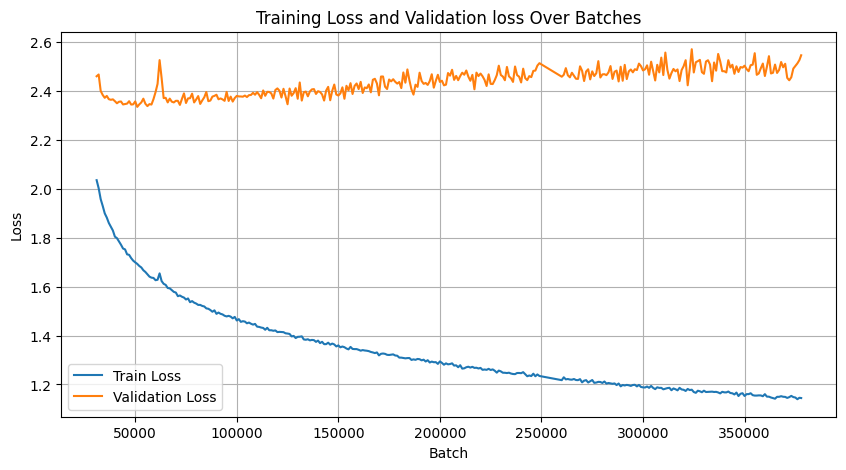

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(batches, train_losses, label="Train Loss")
plt.plot(batches, val_losses, label="Validation Loss")  # marker='o'
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training Loss and Validation loss Over Batches")
plt.legend()
plt.grid()
plt.show()